# Prodigy InfoTech Data Science Internship — Task 3

## Decision Tree Classifier

Build a Decision Tree Classifier to predict whether a customer will subscribe to a term deposit based on demographic and behavioral data.

## Task Objective

The objective of this task is to build a Decision Tree Classifier that predicts whether a customer will subscribe to a term deposit based on demographic and behavioral data.

The Bank Marketing dataset from the UCI Machine Learning Repository is used for this classification problem.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
!pip install ucimlrepo


In [10]:
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

df = X.copy()
df['y'] = y

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [11]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (45211, 17)

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  i

In [12]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [13]:
print("Target variable distribution:")
print(df["y"].value_counts())

print("\nPercentage:")
print(df["y"].value_counts(normalize=True) * 100)

Target variable distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [14]:
# Convert categorical columns into numerical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Display the first 5 rows
df_encoded.head()

,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,y_yes
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,False
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [15]:
print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

Original shape: (45211, 17)
Encoded shape: (45211, 39)


In [16]:
# Separate features (X) and target (y)

X = df_encoded.drop("y_yes", axis=1)
y = df_encoded["y_yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 38)
y shape: (45211,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36168, 38)
Testing data: (9043, 38)


In [18]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [19]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed!
First 20 predictions:
[False False False False False False False  True False False False False
 False False False False False False False False]


In [22]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.8995908437465443

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.98      0.95      7985
        True       0.65      0.30      0.41      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



Confusion Matrix:
[[7816  169]
 [ 739  319]]


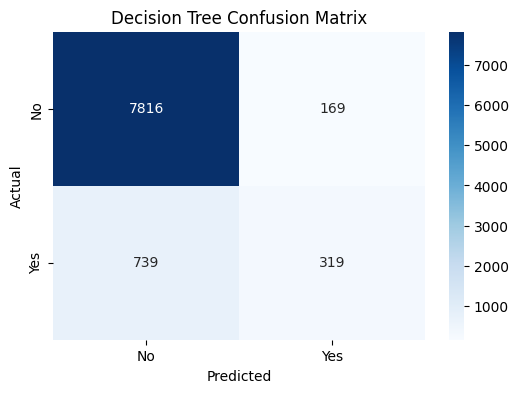

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

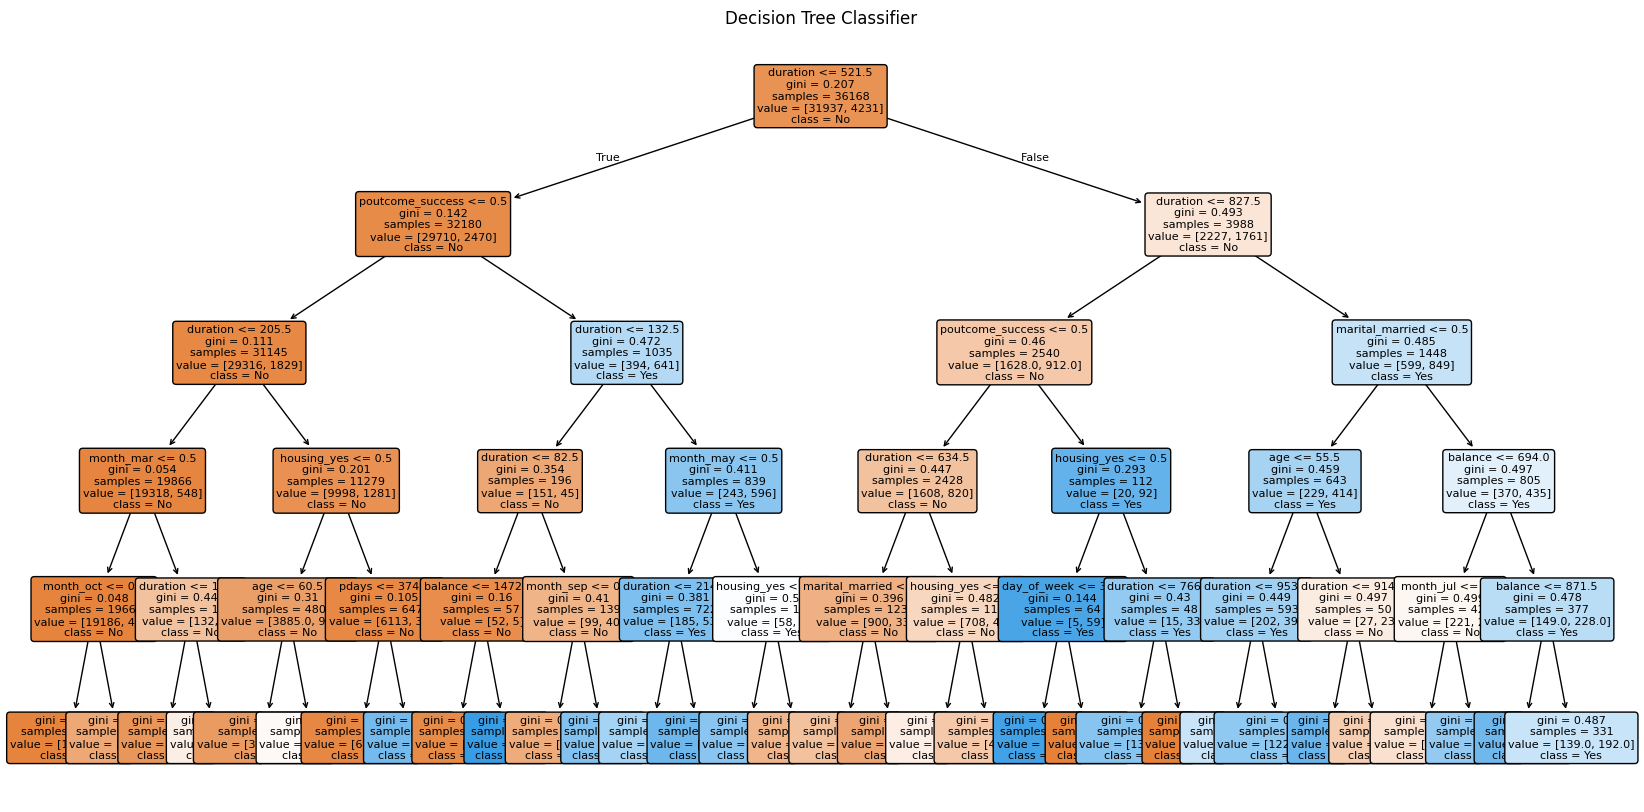

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.show()

In [25]:
print("===== FINAL MODEL RESULTS =====")
print(f"Accuracy: {accuracy:.2%}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

===== FINAL MODEL RESULTS =====
Accuracy: 89.96%

Confusion Matrix:
[[7816  169]
 [ 739  319]]

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.98      0.95      7985
        True       0.65      0.30      0.41      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



## Conclusion

A Decision Tree Classifier was developed to predict whether a customer would subscribe to a term deposit based on demographic and behavioral information from the Bank Marketing dataset.

The dataset was preprocessed by converting categorical variables into numerical features. The data was then divided into training and testing sets using an 80:20 split.

The Decision Tree model achieved an accuracy of approximately 89.96% on the test dataset.

The confusion matrix and classification report were used to evaluate the model's performance. The results also show that the dataset is imbalanced, and the model's recall for customers who subscribed was lower than its performance for customers who did not subscribe.

This project demonstrates the use of data preprocessing, classification, model training, prediction, and evaluation using Python and Scikit-learn.